## Import Libraries

In [233]:
import os
import pandas as pd
import numpy as np
import igraph as ig
from tqdm import tqdm
from collections import defaultdict
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight


## Load dataset

Full dataset consists 31 days of data, with about 3 days of data in val and test. We arbitrarily set block_size to 12 and window_size to 48.



In [234]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_downsampled_1to5_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

# df_train = pd.read_csv('../data/FEwithoutMerchants/FE_train_downsampled_1to5_with_merchants.csv')
# df_val = pd.read_csv('../data/FEwithoutMerchants/FE_validation_without_merchants.csv')
# df_test = pd.read_csv('../data/FEwithoutMerchants/FE_test_without_merchants.csv')

In [235]:
# to check
df_train.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest',
       'oldbalanceDest', 'isFlaggedFraud', 'isFraud',
       'amount_to_oldbalanceOrg', 'day', 'avgAmountToDest',
       'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio',
       'avgAmountPerType', 'p95AmountPerType', 'typeHighValueFlag',
       'amountLog', 'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent',
       'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived',
       'stdReceived', 'numReceived', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName',
       'numUniqueDest', 'numUniqueOrig', 'transactionRecency',
       'transaction_sequence', 'sequence_frequency',
       'is_cashin_transfer_cashout', 'is_transfer_cashout',
       'is_cashin_transfer', 'is_cashout_transfer', 'is_transfer_transfer',
       'is_first_transfer', 'is_cashin_cashout', 'is_early_transaction',
       'sequence_count', 'pctForwarded24h', 'pairFrequency', 'pctUniqueDest',
       'pctUniqueOrig', 'sender_btwn'

## Data Processing
- Convert to categorical columns to ensure XGBoost handles categorical features correctly
- Feature selection

In [236]:
print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'transaction_sequence', 'isFlaggedFraud', 'typeHighValueFlag', 'amountBucket', 
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference 
    combined_cats = pd.Series(
        pd.concat([df_train[col], df_val[col], df_test[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train[col] = pd.Categorical(df_train[col], categories=categories)
    df_val[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test[col]  = pd.Categorical(df_test[col], categories=categories)

Converting categorical columns ...


In [ ]:
# # selected features for all
# selected_features = [
#     # transaction-level features
#     'step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount', 
#     'oldbalanceOrg', 'oldbalanceDest',
#     'amount_to_oldbalanceOrg',
     
                
#     # account-level features
#     'meanSent', 
#     'totalSent', 'stdSent', 'numSent', 
#     'totalReceived',  'numReceived', 
#     'stdReceived', 'meanReceived', 
#     'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 
#     'avgAmountToDest', 
#     'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig', 

#     # transaction pattern features 
#     'transaction_sequence', 'sequence_frequency', 'transactionRecency', 'typeHighValueFlag', 
#     'is_early_transaction',  'sequence_count',
#     'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
#     'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

#     # centrality features
#     'sender_btwn', 'receiver_btwn', 'btwn_diff', 
#     'sender_outdeg_amt', 'sender_indeg_amt', 'receiver_outdeg_amt', 'receiver_indeg_amt',
#     'sender_outdeg_cnt', 'sender_indeg_cnt', 'receiver_outdeg_cnt', 'receiver_indeg_cnt', 
#     'outdeg_amt_diff', 'indeg_amt_diff',
#     'outdeg_cnt_diff', 'indeg_cnt_diff' 
# ]

# selected for 1to5 model with merchants
selected_features = ['amount_to_oldbalanceOrg', 'sequence_frequency', 'transaction_sequence', 'meanReceived', 'oldbalanceDest', 'oldbalanceOrg', 'avgAmountToDest', 'type', 'meanSent', 'totalSent', 'hourOfDay', 'receiver_indeg_amt', 'maxAmountReceived', 'indeg_amt_diff', 'stdReceived', 'amount', 'totalReceived', 'stdAmountReceived', 'amountLog']

# selected for 1to10 model with merchants
# selected_features = ['type', 'amount_to_oldbalanceOrg', 'sequence_frequency', 'oldbalanceDest', 'oldbalanceOrg', 'hourOfDay', 'amountLog', 'avgAmountToDest', 'transaction_sequence', 'meanSent', 'totalSent', 'receiver_indeg_amt', 'indeg_cnt_diff', 'amount', 'stdAmountReceived']

In [238]:
print("Processing training set ...")
Xtrain, ytrain = df_train[selected_features].copy(), df_train["isFraud"].astype(int)

print("Processing validation set ...")
Xval, yval = df_val[selected_features].copy(), df_val["isFraud"].astype(int)

print("Processing test set ...")
Xtest, ytest = df_test[selected_features].copy(), df_test["isFraud"].astype(int)

print("Done!")

Xtrain.columns

Processing training set ...
Processing validation set ...
Processing test set ...
Done!


Index(['amount_to_oldbalanceOrg', 'sequence_frequency', 'transaction_sequence',
       'meanReceived', 'oldbalanceDest', 'oldbalanceOrg', 'avgAmountToDest',
       'type', 'meanSent', 'totalSent', 'hourOfDay', 'receiver_indeg_amt',
       'maxAmountReceived', 'indeg_amt_diff', 'stdReceived', 'amount',
       'totalReceived', 'stdAmountReceived', 'amountLog'],
      dtype='object')

## XGBoost Classifier
### Hyperparameter Tuning

To improve model performance, a **random search** over XGBoost hyperparameters was conducted using a predefined parameter grid.  
The search randomly samples 20 parameter combinations (`n_iter = 20`) from ranges covering model complexity, learning rate, regularization, and subsampling ratios.

Class imbalance between legitimate and fraudulent transactions was handled by:
- Setting **class weights** (`class_weights = {0: 1.0, 1: 2.0}`) to penalize the minority class more heavily.
- Computing **sample weights** for training and validation data to balance the contribution of each class.

For each sampled parameter set:
1. A model was trained on the training set with corresponding sample weights.
2. Performance was evaluated on the validation set using **AUC** (Area Under ROC Curve) and **PR-AUC** (Area Under Precision-Recall Curve).
3. Results were stored and sorted to identify the best-performing configuration.


In [239]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [300, 600, 1000],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0.1, 0.2, 0.5, 0.8, 1],
    'reg_alpha': [0, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2, 3],
}

# n_iter = 3
n_iter = 20
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
results = []

for params in tqdm(param_list, desc="Random Search Hyperparameter Tuning"):
    print("Training model with params:", params)
    model = XGBClassifier(
        **params,
        random_state=42,
        enable_categorical=True,
        eval_metric="aucpr",
        n_jobs=-1
    )

    # Evaluate on validation set 
    model.fit(Xtrain, 
            ytrain,
            eval_set=[(Xval, yval)],
            verbose=False)

    yval_pred = model.predict_proba(Xval)[:, 1]
    pr_auc = average_precision_score(yval, yval_pred)

    results.append({
        **params,
        "pr_auc": pr_auc,
    })
    print(f"Validation PR-AUC: {pr_auc:.6f}")

df_results = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
print(df_results.head(5))

Random Search Hyperparameter Tuning:   0%|          | 0/20 [00:00<?, ?it/s]

Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:   5%|▌         | 1/20 [00:56<17:51, 56.41s/it]

Validation PR-AUC: 0.946967
Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  10%|█         | 2/20 [01:19<11:05, 37.00s/it]

Validation PR-AUC: 0.955855
Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.8, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  15%|█▌        | 3/20 [01:38<08:05, 28.56s/it]

Validation PR-AUC: 0.725999
Training model with params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  20%|██        | 4/20 [02:39<11:00, 41.26s/it]

Validation PR-AUC: 0.942500
Training model with params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.2, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  25%|██▌       | 5/20 [03:10<09:23, 37.57s/it]

Validation PR-AUC: 0.952456
Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  30%|███       | 6/20 [03:57<09:32, 40.90s/it]

Validation PR-AUC: 0.796283
Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  35%|███▌      | 7/20 [05:53<14:08, 65.31s/it]

Validation PR-AUC: 0.942680
Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  40%|████      | 8/20 [07:44<15:59, 79.99s/it]

Validation PR-AUC: 0.937350
Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  45%|████▌     | 9/20 [08:06<11:20, 61.86s/it]

Validation PR-AUC: 0.743947
Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  50%|█████     | 10/20 [09:20<10:55, 65.56s/it]

Validation PR-AUC: 0.950333
Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.5, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  55%|█████▌    | 11/20 [10:14<09:18, 62.04s/it]

Validation PR-AUC: 0.944781
Training model with params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  60%|██████    | 12/20 [10:44<06:59, 52.47s/it]

Validation PR-AUC: 0.932644
Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.005, 'gamma': 0.2, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  65%|██████▌   | 13/20 [11:06<05:02, 43.16s/it]

Validation PR-AUC: 0.596745
Training model with params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  70%|███████   | 14/20 [12:08<04:52, 48.83s/it]

Validation PR-AUC: 0.957467
Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  75%|███████▌  | 15/20 [13:40<05:08, 61.71s/it]

Validation PR-AUC: 0.933758
Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  80%|████████  | 16/20 [14:48<04:14, 63.66s/it]

Validation PR-AUC: 0.921411
Training model with params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.005, 'gamma': 0.2, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  85%|████████▌ | 17/20 [15:13<02:35, 51.94s/it]

Validation PR-AUC: 0.597219
Training model with params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  90%|█████████ | 18/20 [16:28<01:57, 58.91s/it]

Validation PR-AUC: 0.931287
Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  95%|█████████▌| 19/20 [17:05<00:52, 52.57s/it]

Validation PR-AUC: 0.954484
Training model with params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning: 100%|██████████| 20/20 [17:58<00:00, 53.91s/it]

Validation PR-AUC: 0.917743
    subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  \
13        1.0         0.5       0.05           600                 5   
1         0.8         2.0       0.10           300                10   
18        1.0         3.0       0.50           300                 1   
4         1.0         0.5       0.50           300                 1   
9         1.0         3.0       0.10           600                 3   

    max_depth  learning_rate  gamma  colsample_bytree    pr_auc  
13          5          0.005    0.1               0.6  0.957467  
1           5          0.005    0.1               0.6  0.955855  
18          9          0.050    0.1               0.6  0.954484  
4           5          0.005    0.2               0.6  0.952456  
9           5          0.050    0.5               0.6  0.950333  


### Choosing the Best Model
The model with the **highest PR-AUC score** was identified as the best model, since PR-AUC is more informative for imbalanced classification problems (e.g., fraud detection). 


In [240]:
# Best model from Randomized Search
best_model_info = df_results.iloc[0]
best_model_info = best_model_info.to_dict()
best_model_info = {k: int(v) if isinstance(v, float) and v.is_integer() else v
               for k, v in best_model_info.items()}

print("=== Best model hyperparameters from Random Search Hyperparameter Tuning ===")
for k, v in best_model_info.items():
    print(f"{k:<20}: {v}")

# remove metrics from best_model_info to get only parameters
best_model_info.pop("pr_auc", None)
best_params = best_model_info

=== Best model hyperparameters from Random Search Hyperparameter Tuning ===
subsample           : 1
reg_lambda          : 0.5
reg_alpha           : 0.05
n_estimators        : 600
min_child_weight    : 5
max_depth           : 5
learning_rate       : 0.005
gamma               : 0.1
colsample_bytree    : 0.6
pr_auc              : 0.9574667576078514


## Final Model Training
After identifying the optimal hyperparameters from the random search, a final XGBoost model was trained using the combined training and validation datasets.  
Merging these datasets (`Xtrain_full`, `ytrain_full`) allows the model to learn from all available labeled data, improving generalization before final testing.

To maintain balanced learning despite class imbalance, sample weights were recalculated using the same class weight configuration as before.


In [241]:
Xtrain_full = pd.concat([Xtrain, Xval])
ytrain_full = pd.concat([ytrain, yval])

# Final model using tuned parameters
best_xgb = XGBClassifier(
    **best_params,          
    random_state=42,
    enable_categorical=True,
    n_jobs=-1,
    eval_metric="aucpr"
)

best_xgb.fit(Xtrain_full, ytrain_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'aucpr'


## Feature Importance & Feature Selection

A feature importance plot was generated to visualize the relative influence of each variable on the model’s predictions.

Subsequently, a feature selection step was performed by ranking all features based on their importance scores and calculating their cumulative contribution. Features collectively accounting for 95% of the total model importance were retained as the most informative subset.

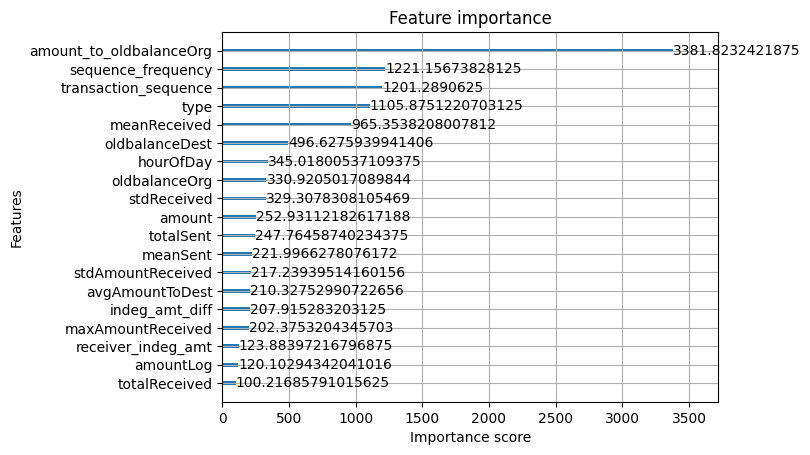

In [242]:
xgb.plot_importance(best_xgb, importance_type='gain')
plt.show()

In [243]:
all_features = pd.DataFrame({'feature': Xtrain_full.columns})
importance_dict = best_xgb.get_booster().get_score(importance_type='gain')

feature_importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
})

# Merge with all features, fill missing with 0
feature_importance_df = all_features.merge(feature_importance_df, on='feature', how='left').fillna(0)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Calculate cumulative importance
feature_importance_df['cumulative_importance'] = (
    feature_importance_df['importance'].cumsum() / feature_importance_df['importance'].sum()
)

print(feature_importance_df.head(20))

top_features = feature_importance_df[
    feature_importance_df['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"Selected {len(top_features)} features explaining 95% of model importance")
print(top_features)

                    feature   importance  cumulative_importance
0   amount_to_oldbalanceOrg  3381.823242               0.299751
1        sequence_frequency  1221.156738               0.407989
2      transaction_sequence  1201.289062               0.514466
7                      type  1105.875122               0.612486
3              meanReceived   965.353821               0.698051
4            oldbalanceDest   496.627594               0.742070
10                hourOfDay   345.018005               0.772651
5             oldbalanceOrg   330.920502               0.801982
14              stdReceived   329.307831               0.831171
15                   amount   252.931122               0.853589
9                 totalSent   247.764587               0.875550
8                  meanSent   221.996628               0.895227
17        stdAmountReceived   217.239395               0.914482
6           avgAmountToDest   210.327530               0.933125
13           indeg_amt_diff   207.915283

## Model Evaluation

To assess the performance of the final XGBoost model, both training and test set predictions were evaluated using Precision–Recall (PR) metrics, which are more informative than accuracy in imbalanced classification settings such as fraud detection.

A secondary plot was generated to examine how Precision, Recall, and F1-score change across different classification thresholds, enabling better selection of an optimal cutoff that balances false positives and false negatives according to business needs.

Train PR-AUC : 0.9962055848226363
Test PR-AUC : 0.9470245879183842


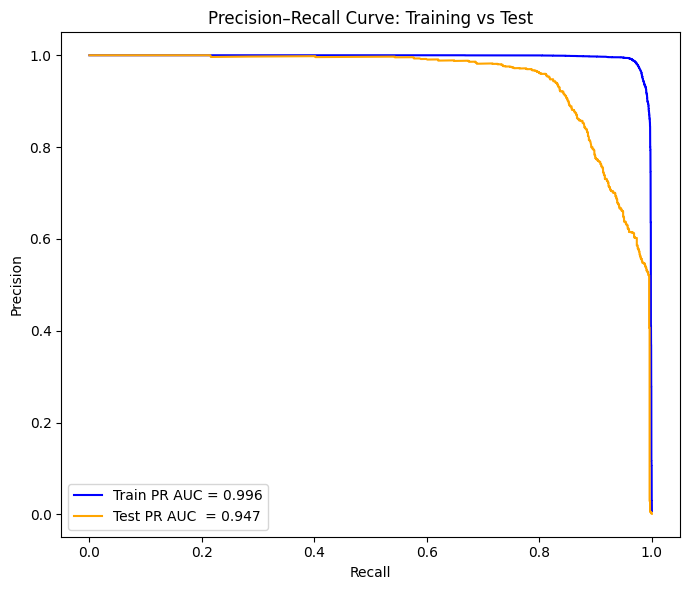

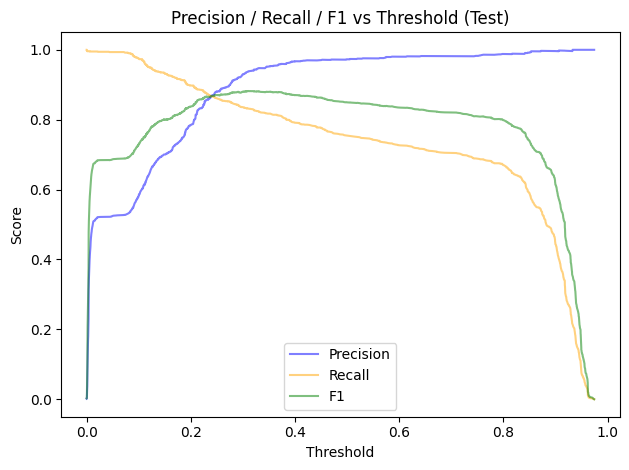

In [244]:
ytrain_proba = best_xgb.predict_proba(Xtrain_full)[:, 1]
ytest_proba = best_xgb.predict_proba(Xtest)[:, 1]
print("Train PR-AUC :", average_precision_score(ytrain_full, ytrain_proba))
print("Test PR-AUC :", average_precision_score(ytest, ytest_proba))

ytrain_true = ytrain_full.astype(int)
ytest_true = ytest.astype(int)

# --- Precision–Recall Curves ---
prec_train, rec_train, thr_pr_train = precision_recall_curve(ytrain_true, ytrain_proba)
prec_test,  rec_test,  thr_pr_test  = precision_recall_curve(ytest_true,  ytest_proba)
ap_train = average_precision_score(ytrain_true, ytrain_proba)
ap_test  = average_precision_score(ytest_true,  ytest_proba)

plt.figure(figsize=(7,6))
plt.plot(rec_train, prec_train, label=f"Train PR AUC = {ap_train:.3f}", color="blue")
plt.plot(rec_test,  prec_test,  label=f"Test PR AUC  = {ap_test:.3f}", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Training vs Test")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- Precision / Recall / F1 vs Threshold ---
thr_test  = np.r_[0.0, thr_pr_test]
f1_test  = 2 * (prec_test  * rec_test)  / np.clip(prec_test  + rec_test,  1e-12, None)

plt.plot(thr_test, prec_test, label="Precision", color="blue", alpha=0.5)
plt.plot(thr_test, rec_test,  label="Recall", color="orange", alpha=0.5)
plt.plot(thr_test, f1_test,   label="F1", color="green", alpha=0.5)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold (Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Choose threshold based on highest F1
best_thr = thr_test[np.argmax(f1_test)]
print(f"Threshold: {best_thr:.4f}")

ytest_pred = (ytest_proba >= best_thr).astype(int)
print("Test Classification Report:")
print(classification_report(ytest, ytest_pred))


Threshold: 0.3104
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.94      0.83      0.88      1232

    accuracy                           1.00    954393
   macro avg       0.97      0.92      0.94    954393
weighted avg       1.00      1.00      1.00    954393



## Save the Model

In [246]:
os.makedirs('../models/XGB/', exist_ok=True)
best_xgb.save_model('../models/XGB/best_xgb_1to5_selected.json')

In [247]:
# # For testing
# best_xgb = XGBClassifier()
# best_xgb.load_model('../models/XGB/best_xgb_1to5_selected_2.json')

# selected_features = selected_features = ['amount_to_oldbalanceOrg', 'sequence_frequency', 'type', 'transaction_sequence', 'meanReceived', 'oldbalanceOrg', 'amount', 'hourOfDay', 'stdAmountReceived', 'avgAmountToDest', 'stdReceived', 'meanSent', 'amountLog']

# Xtrain_full = pd.concat([Xtrain, Xval])
# ytrain_full = pd.concat([ytrain, yval])
# Xtrain_full = Xtrain_full[selected_features]
# ytrain_proba = best_xgb.predict_proba(Xtrain_full)[:, 1]
# ytest_proba = best_xgb.predict_proba(Xtest)[:, 1]

# print("Train PR-AUC :", average_precision_score(ytrain_full, ytrain_proba))
# print("Test PR-AUC :", average_precision_score(ytest, ytest_proba))

# xgb.plot_importance(best_xgb, importance_type='gain')
# plt.show()